# Phân tích Khám phá Dữ liệu Chuyên sâu (Deep-dive EDA) - ISIC 2018
**Mục tiêu phân tích:**
- Khảo sát sự phân bố kích thước ảnh gốc.
- Đánh giá mức độ mất cân bằng lớp (Lesion Area Ratio).
- Phân tích hình thái Bounding Box để tối ưu Anchor Box cho Faster R-CNN.
- Trực quan hóa phân bố màu sắc (RGB) và Bản đồ nhiệt không gian (Spatial Heatmap).

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm

# Cấu hình thẩm mỹ cho biểu đồ chuẩn báo cáo
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'figure.titlesize': 16})

# Đường dẫn (Trỏ vào dữ liệu RAW)
RAW_IMG_DIR = Path("../data/raw/ISIC2018_Task1-2_Training_Input")
RAW_MASK_DIR = Path("../data/raw/ISIC2018_Task1_Training_GroundTruth")

img_files = list(RAW_IMG_DIR.glob("*.jpg"))
print(f"Tổng số mẫu phân tích: {len(img_files)} ảnh")

Tổng số mẫu phân tích: 2594 ảnh


In [2]:
data_records = []
# Khởi tạo ma trận rỗng để cộng dồn tính Heatmap (resize về 256x256 cho nhẹ)
heatmap_matrix = np.zeros((256, 256), dtype=np.float32)

for img_path in tqdm(img_files, desc="Khai thác dữ liệu"):
    img_id = img_path.stem
    mask_path = RAW_MASK_DIR / f"{img_id}_segmentation.png"
    
    if not mask_path.exists(): continue
        
    # Đọc ảnh gốc (Lấy chiều cao, rộng)
    img = cv2.imread(str(img_path))
    h, w, _ = img.shape
    
    # Tính giá trị trung bình 3 kênh màu B, G, R
    mean_b, mean_g, mean_r = cv2.mean(img)[:3]
    
    # Đọc mask
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    
    # Cộng dồn mask vào heatmap
    mask_resized = cv2.resize(mask, (256, 256))
    heatmap_matrix += (mask_resized > 127).astype(np.float32)
    
    # Trích xuất thống kê vùng tổn thương
    coords = cv2.findNonZero(mask)
    if coords is not None:
        bx, by, bw, bh = cv2.boundingRect(coords)
        lesion_area = cv2.countNonZero(mask)
        img_area = h * w
        lesion_ratio = (lesion_area / img_area) * 100 # % diện tích
        
        data_records.append({
            'id': img_id,
            'img_w': w, 'img_h': h, 'img_aspect_ratio': w/h,
            'bbox_w': bw, 'bbox_h': bh, 'bbox_aspect_ratio': bw/bh,
            'lesion_ratio': lesion_ratio,
            'mean_r': mean_r, 'mean_g': mean_g, 'mean_b': mean_b
        })

df = pd.DataFrame(data_records)
print("Trích xuất thành công! Dữ liệu mẫu:")
display(df.head())

Khai thác dữ liệu:   0%|          | 0/2594 [00:00<?, ?it/s]

Trích xuất thành công! Dữ liệu mẫu:


,id,img_w,img_h,img_aspect_ratio,bbox_w,bbox_h,bbox_aspect_ratio,lesion_ratio,mean_r,mean_g,mean_b
0,ISIC_0000000,1022,767,1.332464,852,590,1.444068,46.973238,131.888722,148.384247,170.699430
1,ISIC_0000001,1022,767,1.332464,299,254,1.177165,7.050368,166.313012,162.109372,165.668786
2,ISIC_0000003,1022,767,1.332464,599,652,0.918712,33.656940,190.571154,176.525692,168.369554
3,ISIC_0000004,1022,767,1.332464,539,662,0.814199,34.497381,90.450662,68.360568,79.987706
4,ISIC_0000006,1022,767,1.332464,293,350,0.837143,9.172265,134.110788,147.433253,167.797929


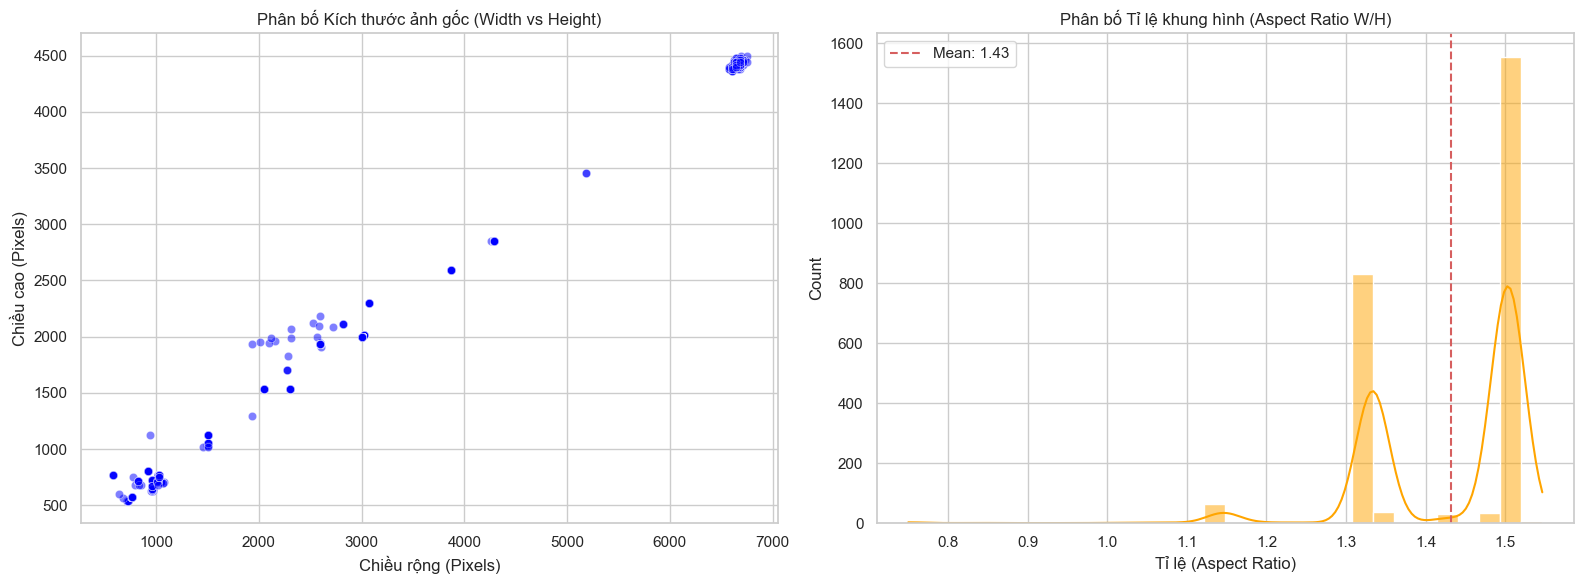

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Đồ thị 1: Scatter plot phân bố Chiều rộng vs Chiều cao
sns.scatterplot(data=df, x='img_w', y='img_h', alpha=0.5, ax=axes[0], color='blue')
axes[0].set_title('Phân bố Kích thước ảnh gốc (Width vs Height)')
axes[0].set_xlabel('Chiều rộng (Pixels)')
axes[0].set_ylabel('Chiều cao (Pixels)')

# Đồ thị 2: Phân bố Tỉ lệ khung hình
sns.histplot(df['img_aspect_ratio'], bins=30, kde=True, ax=axes[1], color='orange')
axes[1].axvline(df['img_aspect_ratio'].mean(), color='r', linestyle='--', label=f"Mean: {df['img_aspect_ratio'].mean():.2f}")
axes[1].set_title('Phân bố Tỉ lệ khung hình (Aspect Ratio W/H)')
axes[1].set_xlabel('Tỉ lệ (Aspect Ratio)')
axes[1].legend()

plt.tight_layout()
plt.show()


Đa số ảnh có kích thước lớn và tỉ lệ ~ 1.33 (4:3). Do đó, khi resize về 512x512, ảnh sẽ bị bóp méo nhẹ. Data Augmentation (Random Crop/Scale) là bắt buộc để model không học theo sự bóp méo này.

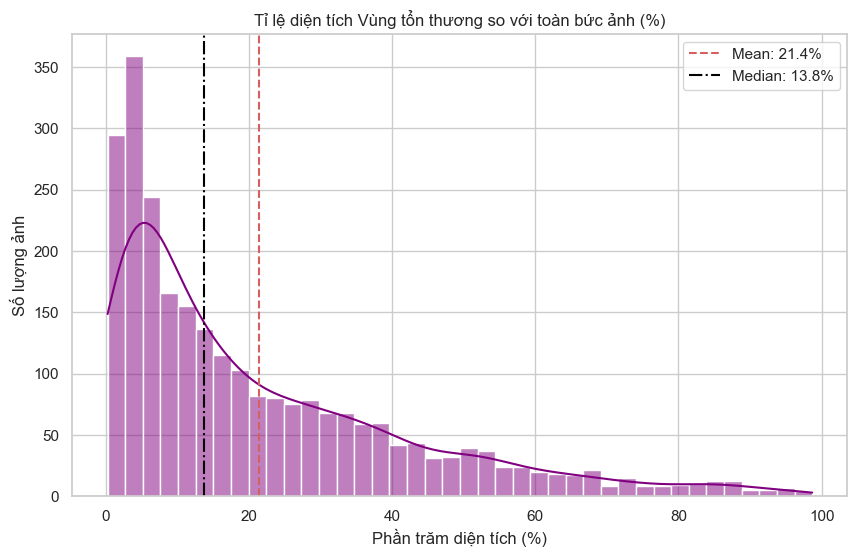

-> Insight: Trung bình tổn thương chỉ chiếm ~ 21.4% bức ảnh. Rất nhiều ảnh tổn thương < 5% diện tích. Điều này chứng minh tuyệt đối KHÔNG ĐƯỢC DÙNG Accuracy làm metric, và BẮT BUỘC dùng Dice Loss/Focal Loss cho U-Net.


In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(df['lesion_ratio'], bins=40, kde=True, color='purple')
plt.axvline(df['lesion_ratio'].mean(), color='r', linestyle='--', label=f"Mean: {df['lesion_ratio'].mean():.1f}%")
plt.axvline(df['lesion_ratio'].median(), color='black', linestyle='-.', label=f"Median: {df['lesion_ratio'].median():.1f}%")

plt.title('Tỉ lệ diện tích Vùng tổn thương so với toàn bức ảnh (%)')
plt.xlabel('Phần trăm diện tích (%)')
plt.ylabel('Số lượng ảnh')
plt.legend()
plt.show()

print(f"-> Insight: Trung bình tổn thương chỉ chiếm ~ {df['lesion_ratio'].mean():.1f}% bức ảnh. Rất nhiều ảnh tổn thương < 5% diện tích. Điều này chứng minh tuyệt đối KHÔNG ĐƯỢC DÙNG Accuracy làm metric, và BẮT BUỘC dùng Dice Loss/Focal Loss cho U-Net.")

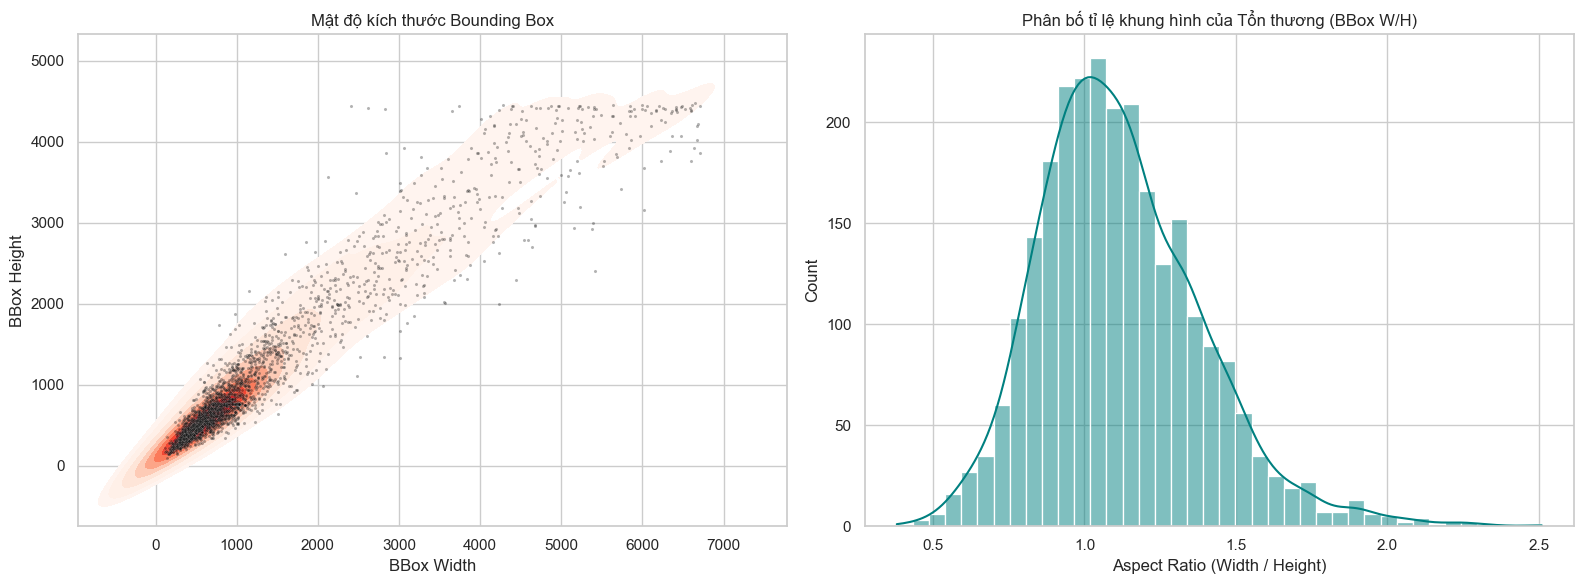

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Đồ thị 1: Jointplot (Scatter + KDE) BBox W vs H
sns.kdeplot(data=df, x='bbox_w', y='bbox_h', cmap="Reds", fill=True, ax=axes[0])
sns.scatterplot(data=df, x='bbox_w', y='bbox_h', s=5, color="black", alpha=0.3, ax=axes[0])
axes[0].set_title('Mật độ kích thước Bounding Box')
axes[0].set_xlabel('BBox Width')
axes[0].set_ylabel('BBox Height')

# Đồ thị 2: Tỉ lệ Aspect Ratio của BBox
sns.histplot(df['bbox_aspect_ratio'], bins=40, kde=True, ax=axes[1], color='teal')
axes[1].set_title('Phân bố tỉ lệ khung hình của Tổn thương (BBox W/H)')
axes[1].set_xlabel('Aspect Ratio (Width / Height)')

plt.tight_layout()
plt.show()


Tổn thương da liễu phần lớn có hình tròn hoặc bầu dục, nên tỉ lệ khung hình của BBox tập trung cực mạnh ở mức 1.0 (Hình vuông). Cấu hình Anchor Boxes của Faster R-CNN cần tập trung vào các tỉ lệ [0.8, 1.0, 1.2] thay vì các tỉ lệ hình chữ nhật dài như [0.5, 2.0] của bộ COCO mặc định

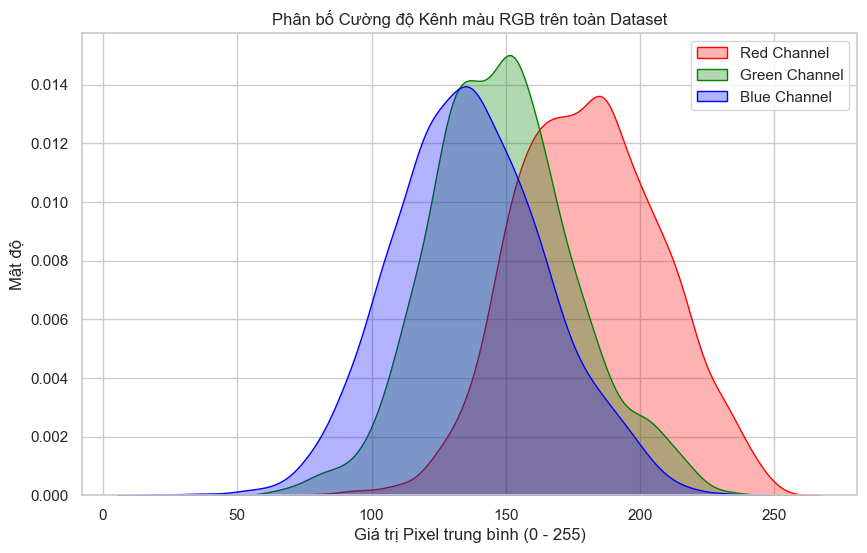

In [6]:
plt.figure(figsize=(10, 6))

sns.kdeplot(df['mean_r'], color='red', label='Red Channel', fill=True, alpha=0.3)
sns.kdeplot(df['mean_g'], color='green', label='Green Channel', fill=True, alpha=0.3)
sns.kdeplot(df['mean_b'], color='blue', label='Blue Channel', fill=True, alpha=0.3)

plt.title('Phân bố Cường độ Kênh màu RGB trên toàn Dataset')
plt.xlabel('Giá trị Pixel trung bình (0 - 255)')
plt.ylabel('Mật độ')
plt.legend()
plt.show()


Màu Đỏ (Red) chi phối rất mạnh do ảnh chụp da và mạch máu. Kênh Blue có phân bố thấp nhất. Khi Normalize dữ liệu vào model, việc sử dụng tham số Mean/Std của ImageNet (được train trên ảnh tự nhiên) có thể chưa tối ưu. Cân nhắc tính Mean/Std riêng cho bộ ISIC này.

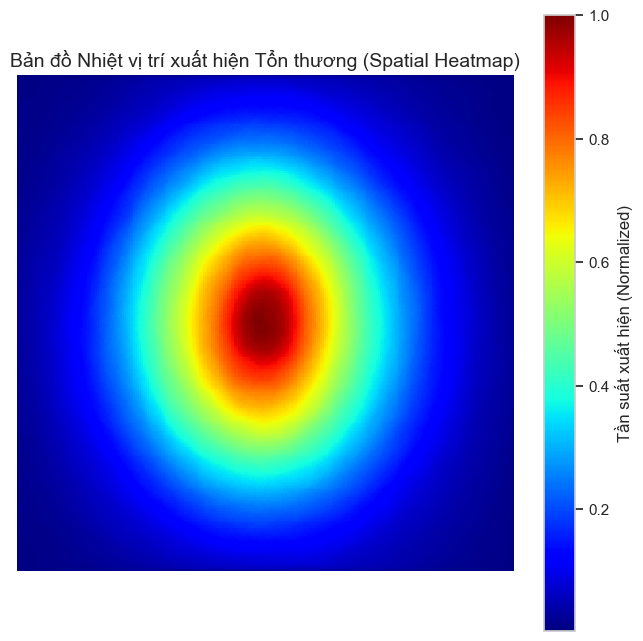

In [7]:
plt.figure(figsize=(8, 8))
# Chuẩn hóa heatmap về khoảng [0, 1]
heatmap_normalized = heatmap_matrix / heatmap_matrix.max()

plt.imshow(heatmap_normalized, cmap='jet', interpolation='nearest')
plt.colorbar(label='Tần suất xuất hiện (Normalized)')
plt.title('Bản đồ Nhiệt vị trí xuất hiện Tổn thương (Spatial Heatmap)', fontsize=14)
plt.axis('off')
plt.show()


Đa số các nốt tổn thương được bác sĩ canh ở chính giữa bức ảnh (Center bias). Nếu model chỉ học vị trí thay vì học đặc trưng, nó sẽ dự đoán sai các ảnh mà nốt ruồi nằm ở mép. Phép Data Augmentation: RandomShift (Dịch chuyển ảnh ngẫu nhiên) là cực kỳ cần thiết.